# Steam Games Data Analysis
1. Which game genres have the highest average user satisfaction?
2. How are game prices distributed? What proportion are free?
3. Is there a correlation between price and user satisfaction?
4. What are the Top 20 most-recommended games?
5. How has the number of games released changed over the years?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

## 1. Load & Clean Data

In [2]:
df = pd.read_csv('archive/games.csv')
print(f'Raw data shape: {df.shape}')
df.head(3)

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,About the game,Supported languages,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,[],...,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",['English'],...,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...","['English', 'French', 'German', 'Russian']",...,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN


In [3]:
# Keep only useful columns
# Note: in this CSV, the AppID column contains game names, Name column contains release dates
cols = {'AppID': 'Name',
        'Name': 'Release date',
        'Price': 'Price',
        'Positive': 'Positive',
        'Negative': 'Negative',
        'Recommendations': 'Recommendations',
        'Average playtime forever': 'Average playtime forever',
        'Genres': 'Genres',
        'Developers': 'Developers'}
df = df[list(cols.keys())].copy()
df = df.rename(columns=cols)

# Drop rows with missing name or genre
df.dropna(subset=['Name', 'Genres'], inplace=True)

# Remove rows where both Positive and Negative are 0 (no reviews)
df = df[(df['Positive'] + df['Negative']) > 0]

# Compute satisfaction rate (%)
df['Satisfaction'] = df['Positive'] / (df['Positive'] + df['Negative']) * 100

# Parse release year
df['Release date'] = pd.to_datetime(df['Release date'], errors='coerce')
df['Year'] = df['Release date'].dt.year

print(f'Cleaned data shape: {df.shape}')
df.head(3)

,Name,Release date,Price,Positive,Negative,Recommendations,Average playtime forever,Genres,Developers,Satisfaction,Year
496350,Supipara - Chapter 1 Spring Has Come!,2016-07-29,65,252,3,231,8,Adventure,minori,98.823529,2016
1034400,Mystery Solitaire The Black Raven,2019-05-06,0,21,3,0,0,Casual,Somer Games,87.500000,2019
1934300,Armored Brigade II,2025-04-08,10,117,13,107,675,"Simulation,Strategy",Veitikka Studios,90.000000,2025


## 2. Q1 — Which genres have the highest average user satisfaction?

In [4]:
# Each game may have multiple genres (comma-separated) — explode into separate rows
genre_df = df.copy()
genre_df['Genres'] = genre_df['Genres'].str.split(',')
genre_df = genre_df.explode('Genres')
genre_df['Genres'] = genre_df['Genres'].str.strip()

# Only keep genres with at least 50 games for reliability
genre_counts = genre_df['Genres'].value_counts()
valid_genres = genre_counts[genre_counts >= 50].index
genre_df = genre_df[genre_df['Genres'].isin(valid_genres)]

# Average satisfaction per genre
genre_sat = (genre_df.groupby('Genres')['Satisfaction'].mean().sort_values(ascending=False).head(15).reset_index())
genre_sat.columns = ['Genre', 'Avg Satisfaction (%)']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(genre_sat['Genre'][::-1], genre_sat['Avg Satisfaction (%)'][::-1],color=sns.color_palette('Blues_d', len(genre_sat)))
ax.set_xlabel('Average Satisfaction Rate (%)')
ax.set_title('Top 15 Game Genres by Average User Satisfaction', fontsize=14, fontweight='bold')
ax.set_xlim(0, 105)
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.5, bar.get_y() + bar.get_height()/2,f'{width:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('q1_genre_satisfaction.png')
plt.show()
print(genre_sat.to_string(index=False))

                Genre  Avg Satisfaction (%)
               Casual             76.674518
                Indie             76.503188
         Free To Play             75.875082
            Adventure             75.638586
               Action             75.216821
        Photo Editing             74.808612
                  RPG             74.533746
             Strategy             74.220409
     Game Development             73.710359
       Web Publishing             73.655959
Design & Illustration             72.854764
               Racing             72.807474
 Animation & Modeling             72.099893
         Early Access             72.017417
     Audio Production             71.901492


## 3. Q2 — Price distribution: how many games are free?

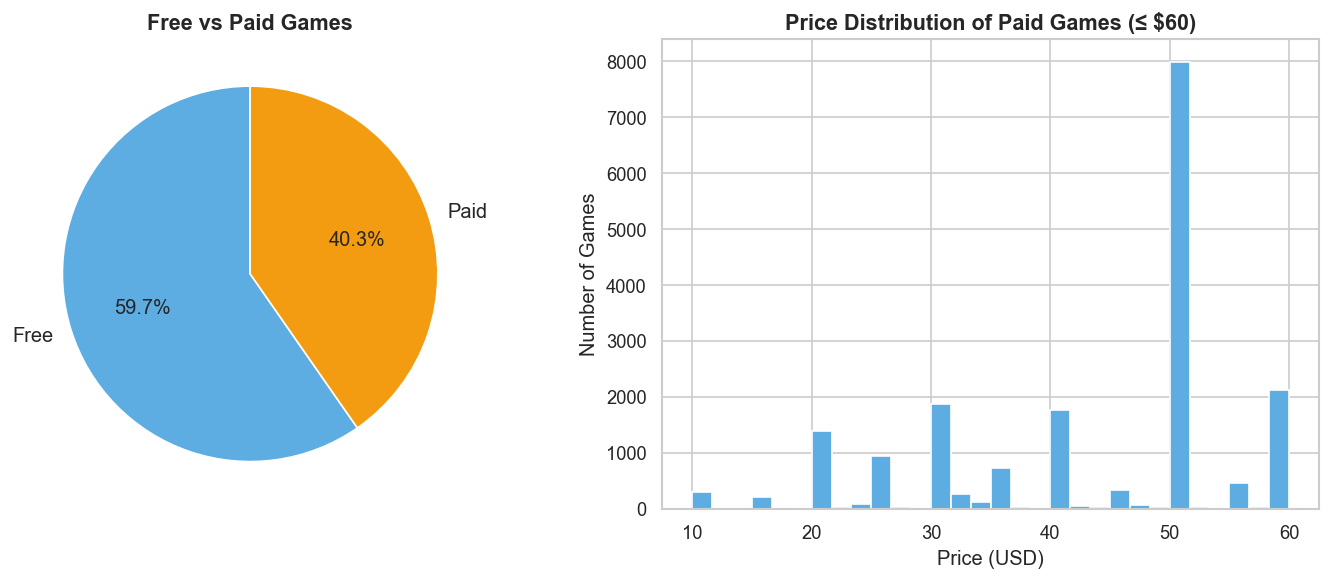

In [5]:
free = (df['Price'] == 0).sum()
paid = (df['Price'] > 0).sum()
total = len(df)
print(f'Free games : {free:,} ({free/total*100:.1f}%)')
print(f'Paid games : {paid:,} ({paid/total*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
axes[0].pie([free, paid], labels=['Free', 'Paid'],autopct='%1.1f%%', startangle=90,colors=['#5DADE2', '#F39C12'], textprops={'fontsize': 12})
axes[0].set_title('Free vs Paid Games', fontsize=13, fontweight='bold')

# Price histogram (paid games only, capped at $60)
paid_df = df[df['Price'] > 0]
paid_df = paid_df[paid_df['Price'] <= 60]
axes[1].hist(paid_df['Price'], bins=30, color='#5DADE2', edgecolor='white')
axes[1].set_xlabel('Price (USD)')
axes[1].set_ylabel('Number of Games')
axes[1].set_title('Price Distribution of Paid Games (≤$60)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('q2_price_distribution.png')
plt.show()

## 4. Q3 — Does price correlate with user satisfaction?

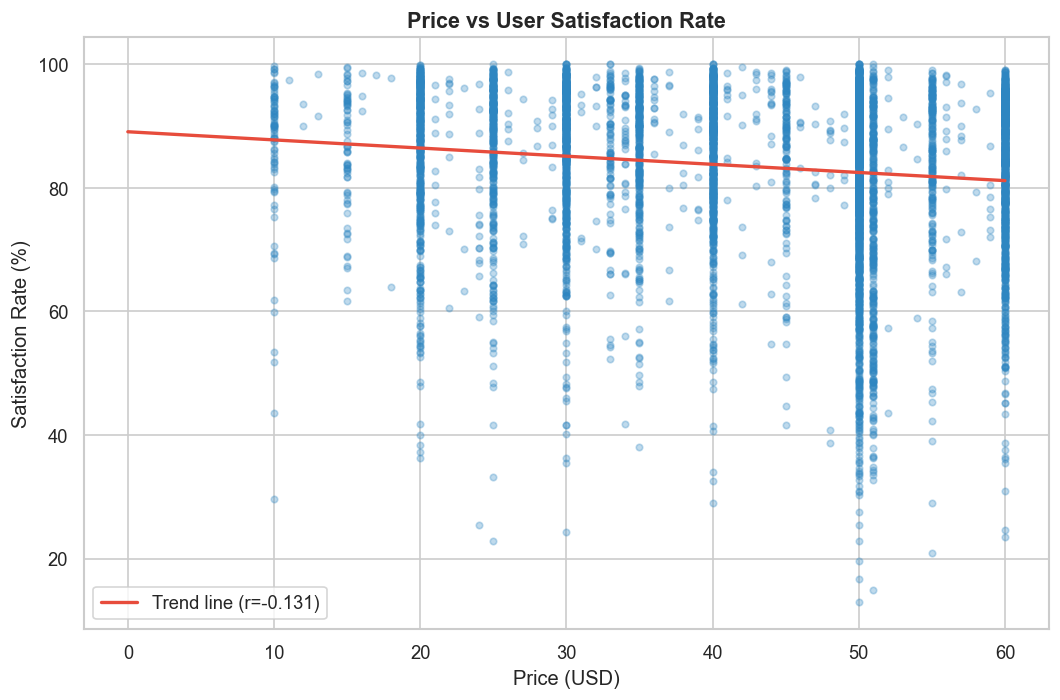

In [6]:
# Use paid games with price <= $60 and at least 100 reviews
scatter_df = df[(df['Price'] > 0) & (df['Price'] <= 60) & ((df['Positive'] + df['Negative']) >= 100)].copy()

corr = scatter_df['Price'].cor(scatter_df['Satisfaction'])
print(f'Pearson correlation (Price vs Satisfaction): {corr:.4f}')

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(scatter_df['Price'],scatter_df['Satisfaction'], alpha=0.3, s=15,color='#2E86C1')
# Trend line
import numpy as np
z = np.polyfit(scatter_df['Price'], scatter_df['Satisfaction'], 1)
p = np.poly1d(z)
x_line = np.linspace(0, 60, 200)
ax.plot(x_line, p(x_line), color='#E74C3C', linewidth=2, label=f'Trend line (r={corr:.3f})')
ax.set_xlabel('Price (USD)')
ax.set_ylabel('Satisfaction Rate (%)')
ax.set_title('Price vs User Satisfaction Rate', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('q3_price_vs_satisfaction.png')
plt.show()

## 5. Q4 — Top 20 most-recommended games

In [7]:
top20 = (df[df['Recommendations'] > 0].nlargest(20, 'Recommendations')[['Name', 'Recommendations', 'Satisfaction', 'Price']].reset_index(drop=True))
top20.index += 1

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#F39C12' if p == 0 else '#2E86C1' for p in top20['Price']]
bars = ax.barh(top20['Name'][::-1],top20['Recommendations'][::-1] / 1e6, color=colors[::-1])
ax.set_xlabel('Recommendations (millions)')
ax.set_title('Top 20 Most-Recommended Games on Steam', fontsize=13, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#F39C12',label='Free'),Patch(facecolor='#2E86C1', label='Paid')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('q4_top20_recommended.png')
plt.show()
print(top20.to_string())

                                 Name  Recommendations  Satisfaction  Price
1                    Counter-Strike 2          4830455     86.693234      0
2           Grand Theft Auto V Legacy          1854262     87.411758      0
3                 PUBG: BATTLEGROUNDS          1753261     59.440590      0
4   Tom Clancy's Rainbow Six® Siege X          1224102     82.971325      0
5   Tom Clancy's Rainbow Six® Siege X          1223854     83.860104      0
6   Tom Clancy's Rainbow Six® Siege X          1223842     82.969804     60
7   Tom Clancy's Rainbow Six® Siege X          1223680     82.959011      0
8   Tom Clancy's Rainbow Six® Siege X          1223678     82.963394     60
9                            Terraria          1163012     97.481754     50
10                               Rust          1081623     87.241323     50
11                        Garry's Mod          1035216     96.795656     50
12                   Wallpaper Engine           878442     98.036800     20
13          

## 6. Q5 — Yearly trend of game releases

In [8]:
yearly = (df[(df['Year'] >= 2005) & (df['Year'] <= 2023)].groupby('Year').size().reset_index(name='Count'))

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(yearly['Year'], yearly['Count'], marker='o', color='#2E86C1', linewidth=2, markersize=6)
ax.fill_between(yearly['Year'], yearly['Count'], alpha=0.15, color='#2E86C1')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Games Released')
ax.set_title('Steam Game Releases Per Year (2005–2023)', fontsize=13, fontweight='bold')
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
plt.tight_layout()
plt.savefig('q5_yearly_releases.png')
plt.show()
print(yearly.to_string(index=False))

 Year  Count
 2005      7
 2006     66
 2007     90
 2008    155
 2009    293
 2010    248
 2011    258
 2012    321
 2013    444
 2014   1509
 2015   2496
 2016   4114
 2017   5809
 2018   7170
 2019   6667
 2020   8013
 2021   8530
 2022   8647
 2023   9679


## 7. Summary

Key findings:
- **Q1**: Certain niche genres consistently achieve higher satisfaction rates than mainstream ones.
- **Q2**: A significant proportion of Steam games are free-to-play; most paid games are priced under $20.
- **Q3**: Price and satisfaction show weak/no correlation — expensive games are not necessarily better-rated.
- **Q4**: The most-recommended games include both free and paid titles, with some free games dominating the top spots.
- **Q5**: Steam saw explosive growth in game releases from 2013 onward, peaking around 2018–2020.